In [1]:
from collections import Counter
import argparse
import os
import json

import numpy as np
from pathlib import Path
from tqdm import tqdm
from p_tqdm import p_map
from scipy.stats import wasserstein_distance

from pymatgen.core.structure import Structure
from pymatgen.core.composition import Composition
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.structure_matcher import StructureMatcher
from matminer.featurizers.site.fingerprint import CrystalNNFingerprint
from matminer.featurizers.composition.composite import ElementProperty

from pymatgen.core.structure import Structure
from pymatgen.core.periodic_table import Element
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator
xrd_calculator = XRDCalculator(wavelength='CuKa', symprec=0.1)
from pymatgen.io.cif import CifWriter

#added by Tsach


from eval_utils import (
    smact_validity, structure_validity, CompScaler, get_fp_pdist,
    load_config, load_data, get_crystals_list, prop_model_eval, compute_cov)


CrystalNNFP = CrystalNNFingerprint.from_preset("ops")
CompFP = ElementProperty.from_preset('magpie')

Percentiles = {
    'mp20': np.array([-3.17562208, -2.82196882, -2.52814761]),
    'carbon': np.array([-154.527093, -154.45865733, -154.44206825]),
    'perovskite': np.array([0.43924842, 0.61202443, 0.7364607]),
}

COV_Cutoffs = {
    'mp20': {'struc': 0.4, 'comp': 10.},
    'carbon': {'struc': 0.2, 'comp': 4.},
    'perovskite': {'struc': 0.2, 'comp': 4},
}
import sys
model_path = '/home/gridsan/tmackey/hydra/singlerun/2024-01-05/mp_20_pv'
num_batches = 1
all_metrics = {}

cfg = load_config(model_path)
eval_model_name = cfg.data.eval_model_name
def get_file_paths(root_path, task, label='', suffix='pt'):
    if label == '':
        out_name = f'eval_{task}.{suffix}'
    else:
        out_name = f'eval_{task}_{label}.{suffix}'
    out_name = os.path.join(root_path, out_name)
    return out_name

recon_file_path = get_file_paths(model_path, 'recon',label='mp_20')

# def get_crystal_array_list(file_path, batch_idx=0):
file_path = recon_file_path
data = load_data(file_path)
def get_crystals_list(
        frac_coords, atom_types, lengths, angles, num_atoms):
    """
    args:
        frac_coords: (num_atoms, 3)
        atom_types: (num_atoms)
        lengths: (num_crystals)
        angles: (num_crystals)
        num_atoms: (num_crystals)
    """
    assert frac_coords.size(0) == atom_types.size(0) == num_atoms.sum()
    assert lengths.size(0) == angles.size(0) == num_atoms.size(0)

    start_idx = 0
    crystal_array_list = []
    for batch_idx, num_atom in enumerate(num_atoms.tolist()):
        cur_frac_coords = frac_coords.narrow(0, start_idx, num_atom)
        cur_atom_types = atom_types.narrow(0, start_idx, num_atom)
        cur_lengths = lengths[batch_idx]
        cur_angles = angles[batch_idx]

        crystal_array_list.append({
            'frac_coords': cur_frac_coords.detach().cpu().numpy(),
            'atom_types': cur_atom_types.detach().cpu().numpy(),
            'lengths': cur_lengths.detach().cpu().numpy(),
            'angles': cur_angles.detach().cpu().numpy(),
        })
        start_idx = start_idx + num_atom
    return crystal_array_list

def get_crystal_array_list(file_path, batch_idx=0):
    data = load_data(file_path)
    crys_array_list = get_crystals_list(
        data['frac_coords'][batch_idx],
        data['atom_types'][batch_idx],
        data['lengths'][batch_idx],
        data['angles'][batch_idx],
        data['num_atoms'][batch_idx])

    if 'input_data_batch' in data:
        batch = data['input_data_batch']
        if isinstance(batch, dict):
            true_crystal_array_list = get_crystals_list(
                batch['frac_coords'], batch['atom_types'], batch['lengths'],
                batch['angles'], batch['num_atoms'])
        else:
            true_crystal_array_list = get_crystals_list(
                batch.frac_coords, batch.atom_types, batch.lengths,
                batch.angles, batch.num_atoms)
    else:
        true_crystal_array_list = None

    return crys_array_list, true_crystal_array_list
class Crystal(object):
    def __init__(self, crys_array_dict):
        self.frac_coords = crys_array_dict['frac_coords']
        self.atom_types = crys_array_dict['atom_types']
        self.lengths = crys_array_dict['lengths']
        self.angles = crys_array_dict['angles']
        self.dict = crys_array_dict

        self.get_structure()
        self.get_composition()
        self.get_validity()
        self.get_fingerprints()
    def get_structure(self):
        if min(self.lengths.tolist()) < 0:
            self.constructed = False
            self.invalid_reason = 'non_positive_lattice'
        else:
            try:
                self.structure = Structure(
                    lattice=Lattice.from_parameters(
                        *(self.lengths.tolist() + self.angles.tolist())),
                    species=self.atom_types, coords=self.frac_coords, coords_are_cartesian=False)
                self.constructed = True
            except Exception:
                self.constructed = False
                self.invalid_reason = 'construction_raises_exception'
            if self.structure.volume < 0.1:
                self.constructed = False
                self.invalid_reason = 'unrealistically_small_lattice'
    def get_composition(self):
        elem_counter = Counter(self.atom_types)
        composition = [(elem, elem_counter[elem])
                       for elem in sorted(elem_counter.keys())]
        elems, counts = list(zip(*composition))
        counts = np.array(counts)
        counts = counts / np.gcd.reduce(counts)
        self.elems = elems
        self.comps = tuple(counts.astype('int').tolist())
    def get_validity(self):
        self.comp_valid = smact_validity(self.elems, self.comps)
        if self.constructed:
            self.struct_valid = structure_validity(self.structure)
        else:
            self.struct_valid = False
        self.valid = self.comp_valid and self.struct_valid
    def get_fingerprints(self):
        elem_counter = Counter(self.atom_types)
        comp = Composition(elem_counter)
        self.comp_fp = CompFP.featurize(comp)
        try:
            site_fps = [CrystalNNFP.featurize(
                self.structure, i) for i in range(len(self.structure))]
        except Exception:
            # counts crystal as invalid if fingerprint cannot be constructed.
            print('oops')
            self.valid = False
            self.comp_fp = None
            self.struct_fp = None
            return
        self.struct_fp = np.array(site_fps).mean(axis=0)
class RecEval(object):

    def __init__(self, pred_crys, gt_crys, stol=0.5, angle_tol=10, ltol=0.3): #original values of stol=0.5, angle_tol=10, ltol=0.3
        assert len(pred_crys) == len(gt_crys)
        self.matcher = StructureMatcher(
            stol=stol, angle_tol=angle_tol, ltol=ltol)
        self.preds = pred_crys
        self.gts = gt_crys

    def get_match_rate_and_rms(self):
        def process_one(pred, gt, is_valid):
            if not is_valid:
                return None
            try:
                rms_dist = self.matcher.get_rms_dist(
                    pred.structure, gt.structure)
                rms_dist = None if rms_dist is None else rms_dist[0]
                return rms_dist
            except Exception:
                return None
        #define a function that gets the diffraction patterns for pred and gt and returns the RMSD between them
        def process_diff_pattern(pred, gt, is_valid):
            if not is_valid:
                return None
            try:
                #get the structures
                pred_structure = pred.structure
                gt_structure = gt.structure
                pred_pattern = xrd_calculator.get_pattern(pred_structure)
                gt_pattern = xrd_calculator.get_pattern(gt_structure)

                pred_adjusted_vector = np.zeros(256)
                minimum = min(256, len(pred_pattern.x))
                pred_adjusted_vector[:minimum] = pred_pattern.x[:minimum]

                gt_adjusted_vector = np.zeros(256)
                minimum = min(256, len(gt_pattern.x))
                gt_adjusted_vector[:minimum] = gt_pattern.x[:minimum]
                
                #calculate the RMSD between the two patterns
                print(pred_adjusted_vector)
                print(gt_adjusted_vector)
                rms_dist = np.sqrt(np.mean((pred_adjusted_vector - gt_adjusted_vector)**2))

                return rms_dist
            except Exception:
                return None    

        validity = [c.valid for c in self.preds]
        
        print(validity)

        rms_dists = []
        evaluate_diff_pattern = False
        if evaluate_diff_pattern:
            diff_dists = []
        for i in tqdm(range(len(self.preds))):
            rms_dists.append(process_one(
                self.preds[i], self.gts[i], validity[i]))
            if evaluate_diff_pattern:
                diff_dists.append(process_diff_pattern(self.preds[i], self.gts[i], validity[i]))
        rms_dists = np.array(rms_dists)
        if evaluate_diff_pattern:
            diff_dists = np.array(diff_dists)
            average_diff_dist = diff_dists[diff_dists != None].mean()
            #print out all the diff dists
        else:
            average_diff_dist = None
        match_rate = sum(rms_dists != None) / len(self.preds)
        mean_rms_dist = rms_dists[rms_dists != None].mean()

        return {'match_rate': match_rate,
                'rms_dist': mean_rms_dist,
                'diff_dist': average_diff_dist,
                'rmsd_values': rms_dists}

    def get_metrics(self):
        return self.get_match_rate_and_rms()
from multiprocessing import Pool, cpu_count

def create_crystal(x):
    return Crystal(x)
num_cores = cpu_count()
print(num_cores)
pool = Pool(processes = num_cores)
from tqdm import tqdm
gt_crys = []
counter = 0 
__, true_crystal_array_list = get_crystal_array_list(file_path, batch_idx=0)
true_crystal_array_list = true_crystal_array_list[0:256]

for x in tqdm(true_crystal_array_list): 
    gt_crys.append(Crystal(x))

num_batches = 64 #total is 64

total_rmsd = []

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/hydra/experimental/compose.py:16: UserWarning: hydra.experimental.compose() is no longer experimental. Use hydra.compose()
  warnings.warn(


80


  0%|          | 0/256 [00:00<?, ?it/s]/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/analysis/local_env.py:4141: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  warnings.warn(
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/analysis/local_env.py:3935: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  warnings.warn(
100%|██████████| 256/256 [01:27<00:00,  2.91it/s]


In [2]:
import os

results_dir = "/home/gridsan/tmackey/cdvae/scripts/1-05-2024_experimental_data/multiple_evals_results"

for eval_num in range(num_batches): 
    print("eval num is ", eval_num)
    crys_array_list, true_crystal_array_list = get_crystal_array_list(file_path, batch_idx=eval_num)

    crys_array_list = crys_array_list[0:256]

    pred_crys = []
    counter = 0 
    for x in tqdm(crys_array_list): 
        pred_crys.append(Crystal(x))

    rec_evaluator = RecEval(pred_crys, gt_crys)
    recon_metrics = rec_evaluator.get_metrics()
    total_rmsd.append(recon_metrics['rmsd_values'])

    file_name = os.path.join(results_dir, "eval_" + str(eval_num) + ".json")
    #save the rmsd values
    np.save(file_name, np.array(total_rmsd))


In [5]:
total_rmsd_og = total_rmsd # for safekeeping

In [6]:
print(total_rmsd[0])

[0.0073427923284093205 0.28023020909618546 None None 0.01046331527162087
 0.011487252093667593 0.08915629545338258 None None None
 0.016587007865019543 None None 0.009284937107634034 0.005074777649641004
 0.021444041705482288 None None None None 0.028989656759210364 None None
 0.01955242014160205 None 0.006917956092699078 0.012449367629300254 None
 None None None 0.003138045668845228 None None 0.008754543367503276 None
 0.017362724322026436 None 0.00814997852139846 0.010675234396427634
 0.002745303360158132 None 0.0068193504008049344 None 0.007361452015516366
 None 0.010008048570530793 0.20437360254042172 None None None None None
 None 0.007347334216674828 0.012790630837418623 0.010629126105367254
 0.010020787979317452 0.009170313964450836 0.00869983578690667 None None
 0.08053936602843562 0.009172927770307312 None 0.1300866831800767 None
 None None None None 0.022232477720861447 None None 0.1910418178229479
 None 0.009623806671061788 None None None 0.024928503286753653
 0.014092436736

In [7]:
total_rmsd_array = np.array([[0 if x is None else x for x in sublist] for sublist in total_rmsd])

total_rmsd_array.shape  # To check the shape of the array (should be 64x256 for your case)

(64, 256)

In [8]:
column_sum = np.sum(total_rmsd_array, axis=0)

In [9]:
column_sum

array([5.18096925e-01, 6.43680706e-01, 6.13973317e-02, 1.91050386e-02,
       6.23723857e-01, 4.77996560e-01, 6.59923950e+00, 0.00000000e+00,
       0.00000000e+00, 8.81484147e-01, 8.84493149e-01, 1.48820926e+00,
       5.24027371e-01, 2.59492708e+00, 5.39708779e-01, 3.21021969e+00,
       4.64958265e-01, 0.00000000e+00, 0.00000000e+00, 3.43359786e-01,
       5.74236177e+00, 0.00000000e+00, 8.61916524e-03, 5.95346125e-01,
       0.00000000e+00, 4.22314736e-01, 4.89577133e-01, 1.16074092e-01,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 4.83101574e-01,
       0.00000000e+00, 9.57420876e-01, 5.52135367e-01, 1.99209998e+00,
       8.80301735e-01, 2.84180684e+00, 5.44289824e-01, 5.00891633e-01,
       4.52214337e-01, 2.77061106e+00, 5.43778900e-01, 0.00000000e+00,
       4.56116973e-01, 4.64465300e-01, 5.02399466e-01, 1.28511859e+01,
       1.92300660e+00, 0.00000000e+00, 3.32352523e-01, 2.04198967e+00,
       5.84309496e-01, 0.00000000e+00, 1.26798699e+00, 8.68216471e-01,
      

In [10]:
np.mean(column_sum > 0)

0.75

In [11]:
column_cumn_sum = np.cumsum(total_rmsd_array, axis=0)

In [12]:
results_per_sample = np.mean(column_cumn_sum > 0, axis = 1) 

In [13]:
results_per_sample.shape

(64,)

In [14]:
import matplotlib.pyplot as plt

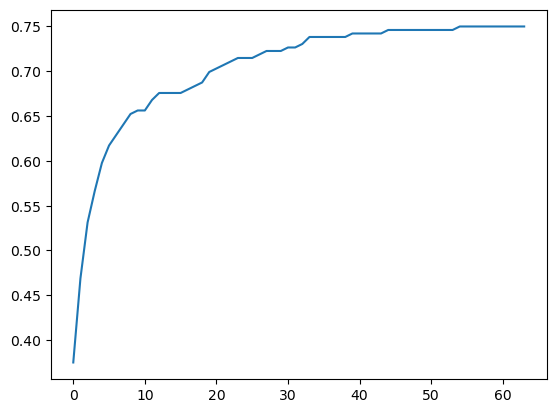

In [15]:
plt.plot(results_per_sample)